# **Project 2: Personality Prediction System Through CV Analysis**


## **1. Install Libraries**



In [1]:
!pip install -q pandas numpy scikit-learn matplotlib joblib transformers datasets accelerate torch

## **2. Import Libraries**

In [2]:
import os
import re
import inspect
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


## **3. Load Dataset**


In [3]:
DATASET_FILENAME = "personality prediction dataset.csv"

if os.path.exists(DATASET_FILENAME):
    dataset_path = DATASET_FILENAME
elif os.path.exists("/content/" + DATASET_FILENAME):
    dataset_path = "/content/" + DATASET_FILENAME
else:
    try:
        from google.colab import files
        print("Please upload your dataset CSV file.")
        uploaded = files.upload()
        dataset_path = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError(
            "Dataset file not found. Please upload 'personality prediction dataset.csv'."
        ) from e

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully.
Dataset shape: (709, 18)


,Candidate_ID,Gender,Age,Education,Skills,Experience,Projects,Achievements,Certifications,Work_Style,CV_Text,openness,neuroticism,conscientiousness,agreeableness,extraversion,Emotional_Stability,Personality (Class label)
0,CAND-0001,Male,17,"BS Psychology, Graduate","Public speaking, teamwork, client communicatio...",6 months internship as Marketing and Customer ...,Customer Feedback Analysis Dashboard; Universi...,Led a student team during a university event,Communication Skills Certificate; Digital Mark...,"Collaborative, energetic, confident in group d...","Education: BS Psychology, Graduate. Skills: Pu...",7,4,7,3,2,5,extraverted
1,CAND-0002,Male,19,"BS Artificial Intelligence, Final Year","Policy analysis, structured reporting, researc...",Completed research assistant role involving su...,Policy Report Summarizer; Python Data Visualiz...,Received appreciation for detailed research re...,SPSS Basics; Academic Research Writing; Python...,"Analytical, focused, detail-oriented, prefers ...","Education: BS Artificial Intelligence, Final Y...",4,5,4,6,6,4,serious
2,CAND-0003,Female,18,"BS Artificial Intelligence, Final Year","Administrative support, communication, schedul...",Worked as quality assurance trainee for data v...,Attendance Management System; Project Document...,Received supervisor appreciation for reliability,Data Entry and Documentation Training; Time Ma...,"Reliable, organized, consistent, follows instr...","Education: BS Artificial Intelligence, Final Y...",7,6,4,5,5,3,dependable
3,CAND-0004,Female,22,"BS Information Technology, 7th Semester","Team collaboration, customer handling, event c...",Worked as Event Coordination Volunteer for uni...,Student Society Website; Public Awareness Camp...,Won best speaker award in a seminar presentation,Leadership and Public Speaking Certificate; Ca...,"People-oriented, persuasive, active in meeting...","Education: BS Information Technology, 7th Seme...",5,6,7,4,3,3,extraverted
4,CAND-0005,Female,19,"BS Public Administration, Graduate","UI design basics, communication, video editing...","Worked on creative campaigns, content planning...",Campus Event Branding Kit; Short Video Campaig...,Recognized for creativity in content and prese...,Creative Writing Certificate; Digital Storytel...,"Energetic, imaginative, flexible, strong in cr...","Education: BS Public Administration, Graduate....",7,4,6,5,4,5,lively


## **4. Exploratory Data Analysis- EDA**



Rows and columns: (709, 18)

Columns:
['Candidate_ID', 'Gender', 'Age', 'Education', 'Skills', 'Experience', 'Projects', 'Achievements', 'Certifications', 'Work_Style', 'CV_Text', 'openness', 'neuroticism', 'conscientiousness', 'agreeableness', 'extraversion', 'Emotional_Stability', 'Personality (Class label)']

Data types:
Candidate_ID                 object
Gender                       object
Age                           int64
Education                    object
Skills                       object
Experience                   object
Projects                     object
Achievements                 object
Certifications               object
Work_Style                   object
CV_Text                      object
openness                      int64
neuroticism                   int64
conscientiousness             int64
agreeableness                 int64
extraversion                  int64
Emotional_Stability           int64
Personality (Class label)    object
dtype: object

Missing val

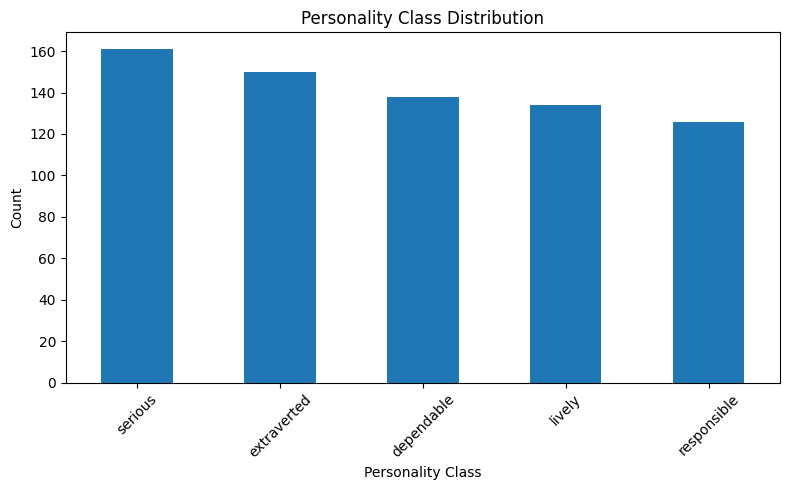

In [4]:
print("Rows and columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

target_col = "Personality (Class label)"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataset.")

print("\nTarget class distribution:")
print(df[target_col].value_counts())

plt.figure(figsize=(8, 5))
df[target_col].value_counts().plot(kind="bar")
plt.title("Personality Class Distribution")
plt.xlabel("Personality Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **5. Data Cleaning**


In [5]:
df = df.copy()

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("")
    else:
        df[col] = df[col].fillna(df[col].median())

# Keep only valid target values
df[target_col] = df[target_col].astype(str).str.strip()
df = df[df[target_col] != ""]

print("Dataset shape after cleaning:", df.shape)
print(df[target_col].value_counts())

Dataset shape after cleaning: (709, 18)
Personality (Class label)
serious        161
extraverted    150
dependable     138
lively         134
responsible    126
Name: count, dtype: int64


## **6. Prepare CV Text for Personality Prediction**


In [6]:
cv_columns = [
    "Education",
    "Skills",
    "Experience",
    "Projects",
    "Achievements",
    "Certifications",
    "Work_Style",
    "CV_Text"
]

available_cv_columns = [col for col in cv_columns if col in df.columns]

if len(available_cv_columns) == 0:
    raise ValueError("No CV text columns found. Please check your dataset columns.")

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s,.;:+#-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def combine_cv_text(row):
    parts = []
    for col in available_cv_columns:
        value = str(row[col]).strip()
        if value:
            parts.append(f"{col}: {value}")
    return " ".join(parts)

df["Combined_CV_Text"] = df.apply(combine_cv_text, axis=1)
df["Clean_CV_Text"] = df["Combined_CV_Text"].apply(clean_text)

# Remove empty text rows
df = df[df["Clean_CV_Text"].str.len() > 10].reset_index(drop=True)

print("CV text prepared successfully.")
print("Final dataset shape:", df.shape)
df[["Combined_CV_Text", "Clean_CV_Text", target_col]].head()

CV text prepared successfully.
Final dataset shape: (709, 20)


,Combined_CV_Text,Clean_CV_Text,Personality (Class label)
0,"Education: BS Psychology, Graduate Skills: Pub...","education: bs psychology, graduate skills: pub...",extraverted
1,"Education: BS Artificial Intelligence, Final Y...","education: bs artificial intelligence, final y...",serious
2,"Education: BS Artificial Intelligence, Final Y...","education: bs artificial intelligence, final y...",dependable
3,"Education: BS Information Technology, 7th Seme...","education: bs information technology, 7th seme...",extraverted
4,"Education: BS Public Administration, Graduate ...","education: bs public administration, graduate ...",lively


## **7. Encode Target Labels**

In [7]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df[target_col])

label_names = list(label_encoder.classes_)
num_labels = len(label_names)

id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

print("Personality labels:")
for i, label in id2label.items():
    print(i, "->", label)

Personality labels:
0 -> dependable
1 -> extraverted
2 -> lively
3 -> responsible
4 -> serious


## **8. Train-Test Split**

In [8]:
X = df["Clean_CV_Text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining label distribution:")
print(pd.Series(y_train).map(id2label).value_counts())

Training samples: 567
Testing samples: 142

Training label distribution:
label
serious        129
extraverted    120
dependable     110
lively         107
responsible    101
Name: count, dtype: int64


## **9. Helper Functions for Model Evaluation**

In [9]:
model_results = []
model_predictions = {}

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    model_predictions[model_name] = y_pred

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    display.plot(ax=ax, cmap=None, values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## **10. Algorithm 1: TF-IDF + Logistic Regression**

In [10]:
logistic_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)

evaluate_model("TF-IDF + Logistic Regression", y_test, logistic_pred)

TF-IDF + Logistic Regression
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

  dependable       1.00      1.00      1.00        28
 extraverted       1.00      1.00      1.00        30
      lively       1.00      1.00      1.00        27
 responsible       1.00      1.00      1.00        25
     serious       1.00      1.00      1.00        32

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



## **11. Algorithm 2: TF-IDF + Linear SVM**

In [11]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    )),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=SEED
    ))
])

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

evaluate_model("TF-IDF + Linear SVM", y_test, svm_pred)

TF-IDF + Linear SVM
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

  dependable       1.00      1.00      1.00        28
 extraverted       1.00      1.00      1.00        30
      lively       1.00      1.00      1.00        27
 responsible       1.00      1.00      1.00        25
     serious       1.00      1.00      1.00        32

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



## **12. Algorithm 3: Random Forest**


In [12]:
to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x,
    accept_sparse=True
)

random_forest_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=2000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    )),
    ("to_dense", to_dense),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)
rf_pred = random_forest_model.predict(X_test)

evaluate_model("Random Forest", y_test, rf_pred)

Random Forest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

  dependable       1.00      1.00      1.00        28
 extraverted       1.00      1.00      1.00        30
      lively       1.00      1.00      1.00        27
 responsible       1.00      1.00      1.00        25
     serious       1.00      1.00      1.00        32

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



## **13. Algorithm 4: Gradient Boosting**



In [13]:
gradient_boosting_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=1500,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    )),
    ("to_dense", to_dense),
    ("classifier", GradientBoostingClassifier(
        random_state=SEED
    ))
])

gradient_boosting_model.fit(X_train, y_train)
gb_pred = gradient_boosting_model.predict(X_test)

evaluate_model("Gradient Boosting", y_test, gb_pred)

Gradient Boosting
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

  dependable       1.00      1.00      1.00        28
 extraverted       1.00      1.00      1.00        30
      lively       1.00      1.00      1.00        27
 responsible       1.00      1.00      1.00        25
     serious       1.00      1.00      1.00        32

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



## **14. Algorithm 5: DistilBERT / BERT Transformer Model**



In [14]:
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"
# TRANSFORMER_MODEL_NAME = "bert-base-uncased"  # Optional BERT alternative

train_hf = Dataset.from_dict({
    "text": X_train.tolist(),
    "labels": y_train.tolist()
})

test_hf = Dataset.from_dict({
    "text": X_test.tolist(),
    "labels": y_test.tolist()
})

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

train_tokenized = train_hf.map(tokenize_batch, batched=True)
test_tokenized = test_hf.map(tokenize_batch, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

training_args_params = {
    "output_dir": "/content/distilbert_personality_model",
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 8,
    "num_train_epochs": 2,
    "weight_decay": 0.01,
    "logging_steps": 10,
    "save_strategy": "epoch",
    "report_to": "none",
    "fp16": torch.cuda.is_available()
}

# Compatible with older and newer Transformers versions
training_signature = inspect.signature(TrainingArguments.__init__)
if "eval_strategy" in training_signature.parameters:
    training_args_params["eval_strategy"] = "epoch"
elif "evaluation_strategy" in training_signature.parameters:
    training_args_params["evaluation_strategy"] = "epoch"

# Keep only parameters supported by the installed Transformers version
training_args_params = {
    key: value
    for key, value in training_args_params.items()
    if key in training_signature.parameters
}

training_args = TrainingArguments(**training_args_params)

trainer_params = {
    "model": model,
    "args": training_args,
    "train_dataset": train_tokenized,
    "eval_dataset": test_tokenized,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics
}

trainer_signature = inspect.signature(Trainer.__init__)
if "processing_class" in trainer_signature.parameters:
    trainer_params["processing_class"] = tokenizer
elif "tokenizer" in trainer_signature.parameters:
    trainer_params["tokenizer"] = tokenizer

trainer = Trainer(**trainer_params)

trainer.train()

prediction_output = trainer.predict(test_tokenized)
transformer_logits = prediction_output.predictions
if isinstance(transformer_logits, tuple):
    transformer_logits = transformer_logits[0]

transformer_pred = np.argmax(transformer_logits, axis=-1)

evaluate_model("DistilBERT / BERT", y_test, transformer_pred)

GPU available: True
GPU name: Tesla T4


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.333292,0.230941,1.000000,1.000000,1.000000,1.000000
2,0.097448,0.081022,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT / BERT
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

  dependable       1.00      1.00      1.00        28
 extraverted       1.00      1.00      1.00        30
      lively       1.00      1.00      1.00        27
 responsible       1.00      1.00      1.00        25
     serious       1.00      1.00      1.00        32

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



## **15. Compare All Models**

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,1.0,1.0,1.0,1.0
1,TF-IDF + Linear SVM,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Gradient Boosting,1.0,1.0,1.0,1.0
4,DistilBERT / BERT,1.0,1.0,1.0,1.0


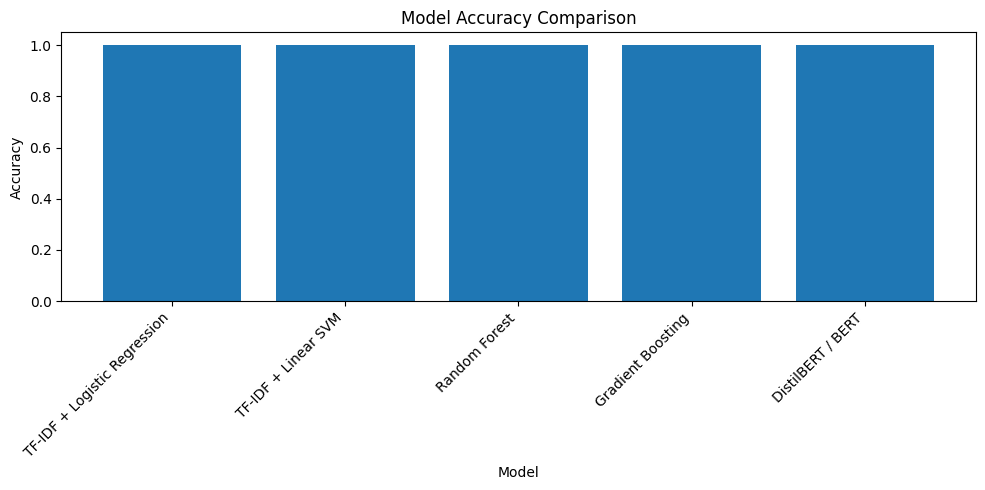

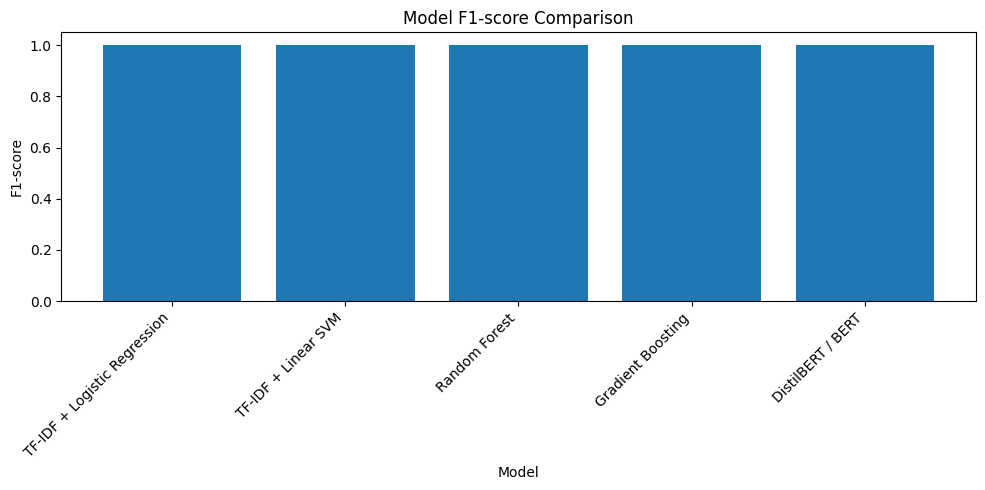

Best model based on F1-score: TF-IDF + Logistic Regression


In [15]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

print("Model Comparison:")
display(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Model F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print("Best model based on F1-score:", best_model_name)

## **16. Confusion Matrix for Each Model**

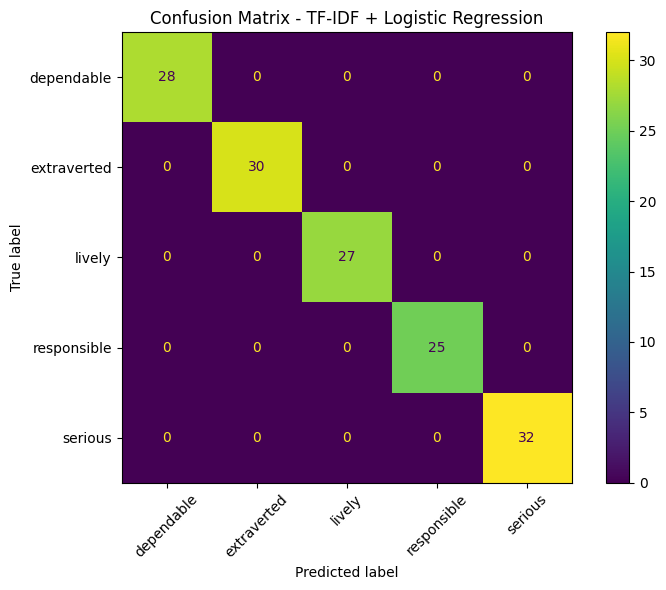

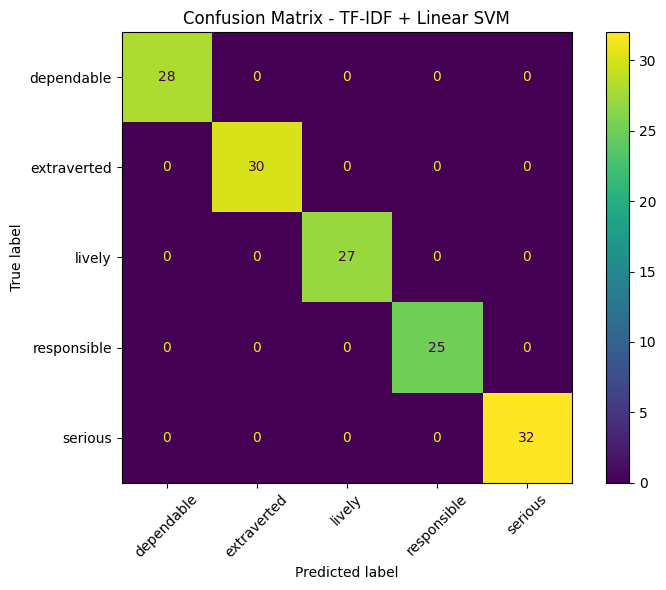

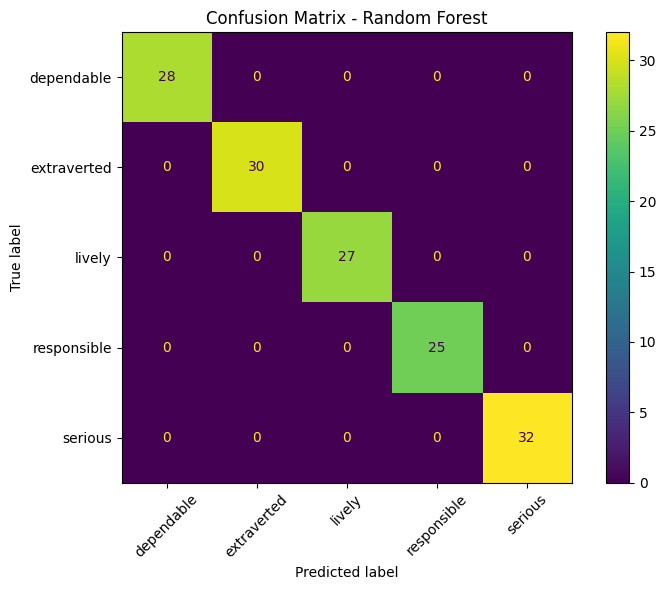

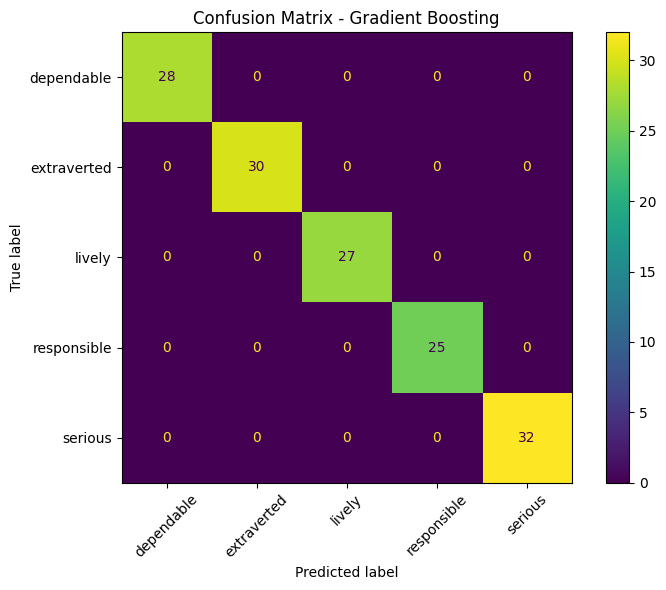

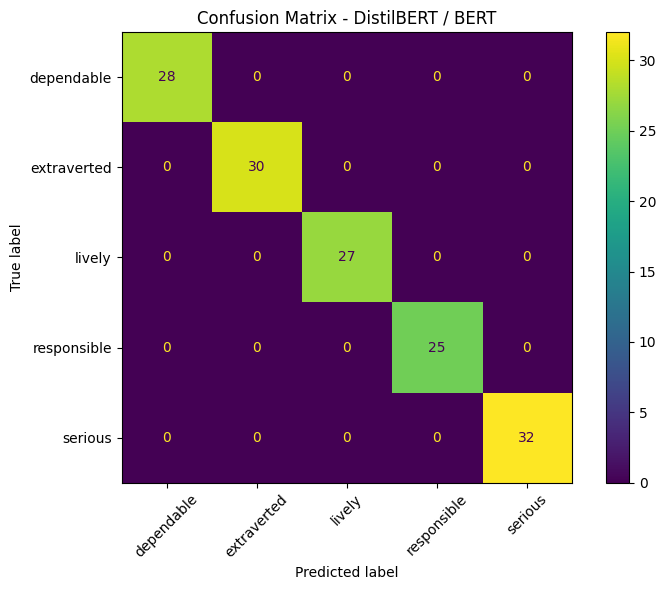

In [16]:
for model_name, preds in model_predictions.items():
    plot_confusion_matrix(model_name, y_test, preds)

## **17. Classification Report of Best Model**

In [17]:
best_preds = model_predictions[best_model_name]

print("Best Model:", best_model_name)
print(classification_report(
    y_test,
    best_preds,
    target_names=label_names,
    zero_division=0
))

Best Model: TF-IDF + Logistic Regression
              precision    recall  f1-score   support

  dependable       1.00      1.00      1.00        28
 extraverted       1.00      1.00      1.00        30
      lively       1.00      1.00      1.00        27
 responsible       1.00      1.00      1.00        25
     serious       1.00      1.00      1.00        32

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



## **18. Predict Personality from New CV Text**



In [18]:
sample_cv_text = '''
Education: BS Computer Science.
Skills: Python, machine learning, data analysis, teamwork, communication, problem solving.
Experience: 1 year internship as a machine learning intern.
Projects: Resume screening system, sentiment analysis project, spam email classifier.
Achievements: Completed multiple AI projects and led a small student project team.
Certifications: Python for Data Science, Machine Learning Basics.
Work style: Responsible, organized, analytical, focused on completing tasks on time.
'''

print("Sample CV Text:")
print(sample_cv_text)

# Use best classical model for simple prediction
classical_models = {
    "TF-IDF + Logistic Regression": logistic_model,
    "TF-IDF + Linear SVM": svm_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

if best_model_name in classical_models:
    final_model_for_prediction = classical_models[best_model_name]
else:
    # If transformer is best, still use SVM as a fast classical fallback for simple CV prediction
    final_model_for_prediction = svm_model

clean_sample = clean_text(sample_cv_text)
predicted_label_id = final_model_for_prediction.predict([clean_sample])[0]
predicted_personality = label_encoder.inverse_transform([predicted_label_id])[0]

print("\nPredicted Personality using selected classical model:")
print(predicted_personality)

Sample CV Text:

Education: BS Computer Science.
Skills: Python, machine learning, data analysis, teamwork, communication, problem solving.
Experience: 1 year internship as a machine learning intern.
Projects: Resume screening system, sentiment analysis project, spam email classifier.
Achievements: Completed multiple AI projects and led a small student project team.
Certifications: Python for Data Science, Machine Learning Basics.
Work style: Responsible, organized, analytical, focused on completing tasks on time.


Predicted Personality using selected classical model:
serious


## **19. Predict Personality Using DistilBERT / BERT**

In [19]:
def predict_with_transformer(text):
    cleaned = clean_text(text)

    inputs = tokenizer(
        cleaned,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    )

    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_id = int(torch.argmax(logits, dim=-1).cpu().numpy()[0])

    return id2label[predicted_id]

transformer_prediction = predict_with_transformer(sample_cv_text)

print("Predicted Personality using DistilBERT / BERT:")
print(transformer_prediction)

Predicted Personality using DistilBERT / BERT:
serious


## **20. Save Best Classical Model and Label Encoder**

In [20]:
os.makedirs("/content/saved_models", exist_ok=True)

joblib.dump(final_model_for_prediction, "/content/saved_models/best_classical_personality_model.pkl")
joblib.dump(label_encoder, "/content/saved_models/label_encoder.pkl")

print("Saved:")
print("/content/saved_models/best_classical_personality_model.pkl")
print("/content/saved_models/label_encoder.pkl")

# Save transformer model and tokenizer
transformer_save_dir = "/content/saved_models/transformer_personality_model"
trainer.save_model(transformer_save_dir)
tokenizer.save_pretrained(transformer_save_dir)

print("Transformer model saved at:", transformer_save_dir)

Saved:
/content/saved_models/best_classical_personality_model.pkl
/content/saved_models/label_encoder.pkl


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer model saved at: /content/saved_models/transformer_personality_model
